=== RESUMEN EJECUTIVO (Monte Carlo + Markov) ===
Registros: 4,935
Simulaciones: 3,000 | Seed: 123
Jornada: 420 min/día | 5 días/semana | 2100 min/semana

Tiempo total estimado:
- Promedio: 123,130 min | 293.17 días | 58.63 semanas
- Mediana : 123,095 min | 293.08 días | 58.62 semanas
- P90     : 125,043 min | 297.72 días | 59.54 semanas
- P95     : 125,631 min | 299.12 días | 59.82 semanas



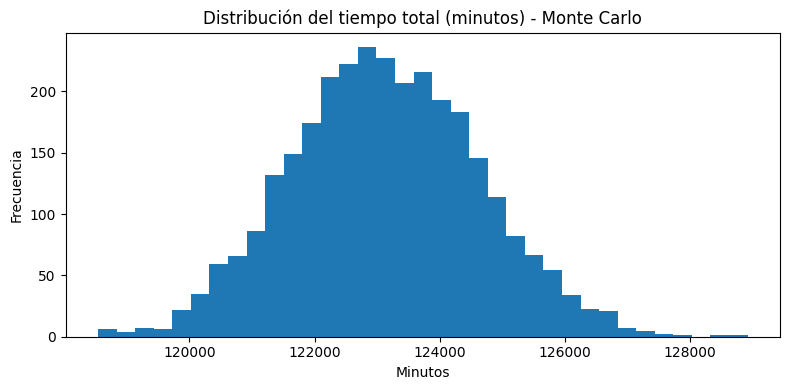

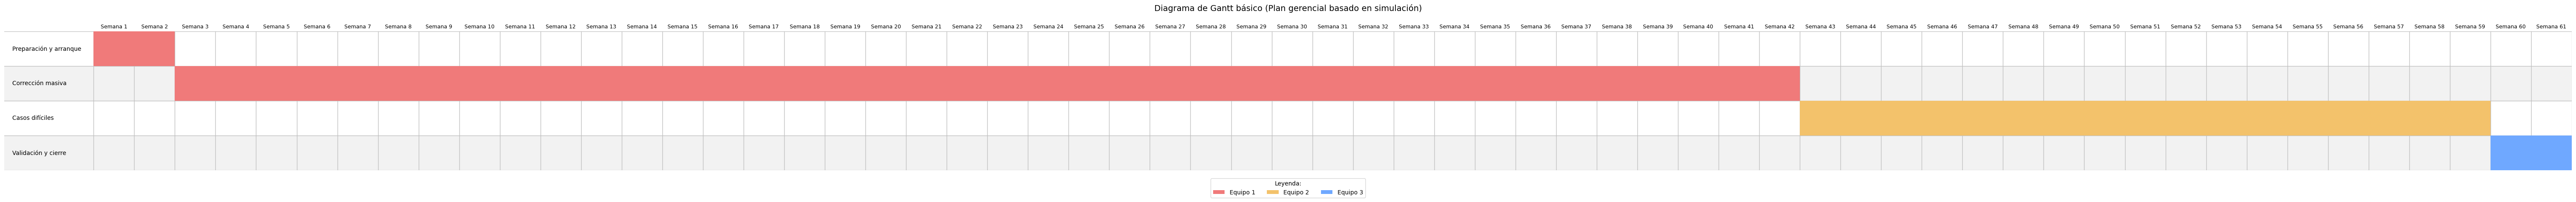

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Patch
import math

# =========================
# Parámetros del enunciado
# =========================
TIME_F, TIME_C, TIME_M = 12, 20, 31               # min por estado (F, C, M)
MIN_PER_WORKDAY = 7 * 60                         # 420 min/día
WORKDAYS_PER_WEEK = 5
MIN_PER_WEEK = MIN_PER_WORKDAY * WORKDAYS_PER_WEEK  # 2100 min/semana laboral

# ==========================================
# 1) Simulación de una corrida (Markov)
# ==========================================
def simulate_one_run(num_records: int, rng: np.random.Generator):
    """
    Devuelve:
      total_minutes: tiempo total en minutos
      minutes_by_state: dict con minutos consumidos en cada estado (0=F,1=C,2=M)
    """
    # 0=F, 1=C, 2=M
    states = np.zeros(num_records, dtype=np.int8)

    total_minutes = 0
    minutes_by_state = {0: 0, 1: 0, 2: 0}

    while states.size > 0:
        counts = np.bincount(states, minlength=3)

        tF = counts[0] * TIME_F
        tC = counts[1] * TIME_C
        tM = counts[2] * TIME_M

        total_minutes += (tF + tC + tM)
        minutes_by_state[0] += tF
        minutes_by_state[1] += tC
        minutes_by_state[2] += tM

        u = rng.random(states.size)
        new_states = []

        # Desde Fácil: 60% DONE, 30%->C, 10%->M
        mask_F = (states == 0)
        if mask_F.any():
            uF = u[mask_F]
            toC = (uF >= 0.60) & (uF < 0.90)
            toM = (uF >= 0.90)
            if toC.any(): new_states.append(np.full(toC.sum(), 1, dtype=np.int8))
            if toM.any(): new_states.append(np.full(toM.sum(), 2, dtype=np.int8))

        # Desde Complicada: 90% DONE, 10%->M
        mask_C = (states == 1)
        if mask_C.any():
            uC = u[mask_C]
            toM = (uC >= 0.90)
            if toM.any(): new_states.append(np.full(toM.sum(), 2, dtype=np.int8))

        # Desde Muy Compleja: 10% DONE, 89%->F, 1%->C
        mask_M = (states == 2)
        if mask_M.any():
            uM = u[mask_M]
            toF = (uM >= 0.10) & (uM < 0.99)
            toC = (uM >= 0.99)
            if toF.any(): new_states.append(np.full(toF.sum(), 0, dtype=np.int8))
            if toC.any(): new_states.append(np.full(toC.sum(), 1, dtype=np.int8))

        states = np.concatenate(new_states) if new_states else np.array([], dtype=np.int8)

    return total_minutes, minutes_by_state


# ==========================================
# 2) Monte Carlo (muchas simulaciones)
# ==========================================
def monte_carlo(num_records: int, n_sims: int = 3000, seed: int = 123):
    rng = np.random.default_rng(seed)

    totals = np.empty(n_sims, dtype=np.int64)
    # Para promediar carga por estado a través de simulaciones
    state_minutes = np.zeros((n_sims, 3), dtype=np.int64)

    for i in range(n_sims):
        total_m, m_by_state = simulate_one_run(num_records, rng)
        totals[i] = total_m
        state_minutes[i, 0] = m_by_state[0]
        state_minutes[i, 1] = m_by_state[1]
        state_minutes[i, 2] = m_by_state[2]

    # Estadísticos del total
    mean_total = float(totals.mean())
    median_total = float(np.percentile(totals, 50))
    p90_total = float(np.percentile(totals, 90))
    p95_total = float(np.percentile(totals, 95))

    # Promedio de minutos por estado (para construir el Gantt estable)
    mean_state = state_minutes.mean(axis=0)  # [F, C, M]

    return {
        "totals": totals,
        "mean_total": mean_total,
        "median_total": median_total,
        "p90_total": p90_total,
        "p95_total": p95_total,
        "mean_state_minutes": mean_state,  # vector [F,C,M]
        "n_sims": n_sims,
        "seed": seed,
        "num_records": num_records
    }


# ==========================================
# 3) Convertir a fases “para jefe”
# ==========================================
def build_manager_phases_from_means(mean_total_minutes: float, mean_state_minutes):
    """
    Fases entendibles para gerencia.
    - Preparación y arranque: 2% del total
    - Validación y cierre: 3% del total
    - Resto: Corrección masiva vs Casos difíciles usando la carga promedio por estado
    """
    prep = 0.02 * mean_total_minutes
    close = 0.03 * mean_total_minutes
    remaining = mean_total_minutes - prep - close

    tF, tC, tM = mean_state_minutes

    # Reparto defendible de Complicada: 60% masiva, 40% difíciles
    masiva_effort = tF + 0.60 * tC
    dificil_effort = tM + 0.40 * tC
    denom = masiva_effort + dificil_effort if (masiva_effort + dificil_effort) > 0 else 1

    masiva = remaining * (masiva_effort / denom)
    dificiles = remaining * (dificil_effort / denom)

    return [
        ("Preparación y arranque", prep, "Equipo 1"),
        ("Corrección masiva", masiva, "Equipo 1"),
        ("Casos difíciles", dificiles, "Equipo 2"),
        ("Validación y cierre", close, "Equipo 3"),
    ]


# ==========================================
# 4) Gantt estilo tabla (como tu imagen)
# ==========================================
def plot_gantt_grid_style(tasks, n_weeks, title="Diagrama de Gantt"):
    team_colors = {
        "Equipo 1": "#f07a7a",  # rojo suave
        "Equipo 2": "#f3c26b",  # naranja suave
        "Equipo 3": "#6fa8ff",  # azul suave
    }

    n_tasks = len(tasks)

    fig_w = max(10, n_weeks * 1.0)
    fig_h = max(5, n_tasks * 0.8)
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))

    ax.set_xlim(-2.2, n_weeks)
    ax.set_ylim(0, n_tasks)

    # Filas alternadas
    for r in range(n_tasks):
        if r % 2 == 0:
            ax.add_patch(Rectangle((-2.2, r), n_weeks + 2.2, 1,
                                   facecolor="#f2f2f2", edgecolor="none", zorder=0))

    # Grid
    for w in range(n_weeks + 1):
        ax.plot([w, w], [0, n_tasks], color="#bfbfbf", linewidth=1, zorder=1)
    for r in range(n_tasks + 1):
        ax.plot([-2.2, n_weeks], [r, r], color="#bfbfbf", linewidth=1, zorder=1)

    # Encabezados de semanas
    ax.set_xticks([w + 0.5 for w in range(n_weeks)])
    ax.set_xticklabels([f"Semana {w+1}" for w in range(n_weeks)], fontsize=9)
    ax.xaxis.tick_top()
    ax.tick_params(axis="x", length=0)
    ax.set_yticks([])
    ax.tick_params(axis="y", length=0)

    # Nombres de tareas a la izquierda
    for i, t in enumerate(tasks):
        ax.text(-2.0, n_tasks - i - 0.5, t["name"], va="center", ha="left", fontsize=10)

    # Bloques coloreados
    for i, t in enumerate(tasks):
        row_y = n_tasks - i - 1
        start = t["start"] - 1
        dur = t["duration"]
        color = team_colors.get(t["team"], "#cccccc")
        ax.add_patch(Rectangle((start, row_y), dur, 1, facecolor=color, edgecolor="none", zorder=2))

    ax.set_title(title, pad=35, fontsize=14)

    handles = [Patch(facecolor=c, label=k) for k, c in team_colors.items()]
    ax.legend(handles=handles, loc="lower center", bbox_to_anchor=(0.5, -0.22),
              ncol=3, frameon=True, title="Leyenda:")

    for spine in ax.spines.values():
        spine.set_visible(False)

    plt.tight_layout()
    plt.show()


# ==========================================
# 5) Main: imprime resumen + dibuja Gantt
# ==========================================
if __name__ == "__main__":
    NUM_REGISTROS = 4935
    N_SIMS = 3000          # <- aquí defines cuántas simulaciones
    SEED = 123

    res = monte_carlo(NUM_REGISTROS, n_sims=N_SIMS, seed=SEED)

    def fmt_time(mins):
        days = mins / MIN_PER_WORKDAY
        weeks = days / WORKDAYS_PER_WEEK
        return mins, days, weeks

    mean_m, mean_d, mean_w = fmt_time(res["mean_total"])
    med_m, med_d, med_w = fmt_time(res["median_total"])
    p90_m, p90_d, p90_w = fmt_time(res["p90_total"])
    p95_m, p95_d, p95_w = fmt_time(res["p95_total"])

    print("=== RESUMEN EJECUTIVO (Monte Carlo + Markov) ===")
    print(f"Registros: {res['num_records']:,}")
    print(f"Simulaciones: {res['n_sims']:,} | Seed: {res['seed']}")
    print(f"Jornada: 420 min/día | 5 días/semana | 2100 min/semana\n")

    print("Tiempo total estimado:")
    print(f"- Promedio: {mean_m:,.0f} min | {mean_d:,.2f} días | {mean_w:,.2f} semanas")
    print(f"- Mediana : {med_m:,.0f} min | {med_d:,.2f} días | {med_w:,.2f} semanas")
    print(f"- P90     : {p90_m:,.0f} min | {p90_d:,.2f} días | {p90_w:,.2f} semanas")
    print(f"- P95     : {p95_m:,.0f} min | {p95_d:,.2f} días | {p95_w:,.2f} semanas\n")

    # Histograma (opcional para tu “estrategia visual”)
    plt.figure(figsize=(8,4))
    plt.hist(res["totals"], bins=35)
    plt.title("Distribución del tiempo total (minutos) - Monte Carlo")
    plt.xlabel("Minutos")
    plt.ylabel("Frecuencia")
    plt.tight_layout()
    plt.show()

    # Construir fases promedio y Gantt
    phases = build_manager_phases_from_means(res["mean_total"], res["mean_state_minutes"])

    tasks = []
    current_week = 1
    for name, mins, team in phases:
        dur_weeks = max(1, int(math.ceil(mins / MIN_PER_WEEK)))
        tasks.append({"name": name, "start": current_week, "duration": dur_weeks, "team": team})
        current_week += dur_weeks

    total_weeks = current_week - 1
    plot_gantt_grid_style(
        tasks=tasks,
        n_weeks=total_weeks,
        title="Diagrama de Gantt básico (Plan gerencial basado en simulación)"
    )
